# Welcome to RISK Quickstart

This notebook provides a minimal working example of Regional Inference of Significant Kinships (RISK), a framework for clustering, overrepresentation analysis, and visualization of biological networks.

In this quickstart, we analyze the yeast protein-protein interaction network from Michaelis et al. (2023), which includes 3,839 proteins and 30,955 interactions, and annotate clusters using GO Biological Process (GO BP) terms.

RISK treats cluster-level enrichment as the statistical unit, then maps significant results back onto the network for interpretation.

You will learn how to:
- Load a network and an annotation file
- Run Louvain clustering
- Test enrichment with a permutation model
- Build a graph object and inspect a summary table
- Render a publication-style network plot

Expected input files in `data`:
- `cytoscape/michaelis_2023.cys`
- `json/annotation/go_biological_process.json`

For full API coverage and additional examples, see the [RISK documentation](https://riskportal.github.io/risk-docs/).


In [1]:
# Import RISK
import risk as r
from risk import RISK

# Import standard libraries
import os
from pathlib import Path

# Print RISK version
print(f"RISK version: {r.__version__}")

# Set working directory if running in a Binder / notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

RISK version: 0.1.6


---

## Initialize RISK

Initialize a `RISK` instance to run the analysis workflow and record parameters.


In [2]:
# Initialize RISK
risk = RISK(verbose=True)

---

## Load the network

Load the interaction network into RISK. This quickstart uses a Cytoscape `.cys` file.


In [3]:
# Load the network from a Cytoscape file for RISK analysis
network = risk.load_network_cytoscape(
    filepath="./data/cytoscape/michaelis_2023.cys",
    source_label="source",
    target_label="target",
    compute_sphere=True,
    surface_depth=0.1,
    min_edges_per_node=1,
)

---------------
Loading network
---------------
Filetype: Cytoscape
Filepath: ./data/cytoscape/michaelis_2023.cys
Minimum edges per node: 1
Projection: Sphere
Surface depth: 0.1
Initial node count: 3839
Final node count: 3839
Initial edge count: 30955
Final edge count: 30955


---

## Load annotations

Load biological annotations and map them to nodes in the network. This quickstart uses a JSON GO BP annotation file.


In [4]:
# Load GO Biological Process (BP) annotations from a JSON file and associate with the network
annotation = risk.load_annotation_json(
    network=network,
    filepath="./data/json/annotation/go_biological_process.json",
    min_nodes_per_term=5,
    max_nodes_per_term=75,
)

------------------
Loading annotation
------------------
Filetype: JSON
Filepath: ./data/json/annotation/go_biological_process.json
Minimum number of nodes per annotation term: 5
Maximum number of nodes per annotation term: 75
Number of input annotation terms: 2214
Number of kept annotation terms: 1293


---

## Cluster the network

Run Louvain clustering to detect communities for downstream significance testing. The `fraction_shortest_edges` argument controls the rank-based fraction of shortest edges retained before clustering.


In [5]:
# Detect Louvain communities for downstream analysis
clusters = risk.cluster_louvain(
    network=network,
    fraction_shortest_edges=0.25,
    resolution=5.0,
    random_seed=887,
)
print(f"Louvain clusters: shape={clusters.shape}, nnz={clusters.getnnz()}")

------------------
Computing clusters
------------------
Clustering: 'louvain'
Edge length threshold: 0.25
Resolution: 5.0
Random seed: 887
Louvain clusters: shape=(3839, 3839), nnz=38212


---

## Run significance testing

Evaluate annotation enrichment with the permutation test (`risk.run_permutation`).


In [6]:
# Compute annotation significance via the permutation test
stats_permutation = risk.run_permutation(
    annotation=annotation,
    clusters=clusters,
    score_metric="stdev",
    null_distribution="network",
    num_permutations=100,  # Use 100 for quicker testing; increase for real analysis
    random_seed=887,
    max_workers=1,
)
print("Permutation test complete")

------------------------
Running permutation test
------------------------
Cluster scoring metric: 'stdev'
Number of permutations: 100
Maximum workers: 1
Null distribution: 'network'


Total progress: 100%|██████████| 100/100 [00:04<00:00, 20.86it/s]


Permutation test complete


---

## Build the analysis graph

Create a `Graph` object from the network, annotations, and statistical results for downstream analysis and plotting.


In [7]:
# Generate a Graph object for analysis
graph = risk.load_graph(
    network=network,
    annotation=annotation,
    stats_results=stats_permutation,
    tail="right",
    pval_cutoff=0.05,
    fdr_cutoff=1.00,
    display_prune_threshold=0.125,
    linkage_criterion="distance",
    linkage_method="single",
    linkage_metric="sokalmichener",
    linkage_threshold="auto",
    min_cluster_size=5,
    max_cluster_size=1_000,
)

# Access key Graph attributes
domain_id_to_node_ids_map = graph.domain_id_to_node_ids_map
domain_id_to_node_labels_map = graph.domain_id_to_node_labels_map
domain_id_to_domain_terms_map = graph.domain_id_to_domain_terms_map
node_label_to_significance_map = graph.node_label_to_significance_map

----------------------------
Finding significant clusters
----------------------------
p-value cutoff: 0.05
FDR BH cutoff: 1.0
Significance tail: 'right' (enrichment)
-------------------------------
Processing significant clusters
-------------------------------
Display prune threshold: 0.125
-----------------------
Finding top annotations
-----------------------
Min cluster size: 5
Max cluster size: 1000
------------------------------
Grouping clusters into domains
------------------------------


Evaluating linkage methods and metrics: 100%|██████████| 1/1 [00:00<00:00]


Linkage criterion: 'distance'
Linkage method: 'single'
Linkage metric: 'sokalmichener'
Linkage threshold: 0.116


---

## Summarize results

Use `graph.summary.load()` to generate a pandas DataFrame for domain-level result inspection.


In [8]:
# Load analysis summary into a DataFrame
loaded_summary = graph.summary.load()
loaded_summary.head()

------------------------
Loading analysis summary
------------------------


,Domain ID,Annotation,Matched Members,Matched Count,Raw Enrichment P-value,Raw Enrichment Q-value,Raw Depletion P-value,Raw Depletion Q-value,Domain Enrichment P-value,Domain Enrichment Q-value,Domain Depletion P-value,Domain Depletion Q-value
0,-1,maintenance of protein location in cell,,0,0.01,0.760588,0.57,0.984466,1.00,1.0,1.0,1.0
1,19,mRNA splice site recognition,CDC40;ISY1;LUC7;NAM8;PRP28;PRP39;PRP42;PRP8;PR...,11,0.01,1.000000,0.74,0.984466,0.01,1.0,1.0,1.0
2,-1,transsulfuration,,0,1.00,1.000000,0.87,0.984466,1.00,1.0,1.0,1.0
3,-1,signal peptide processing,,0,0.01,0.307857,0.87,0.984466,1.00,1.0,1.0,1.0
4,-1,regulation of phosphatidylinositol dephosphory...,,0,0.01,0.808125,0.88,0.984466,1.00,1.0,1.0,1.0


---

## Visualize the network

Render the clustered network with `risk.load_plotter`, including nodes, edges, contours, and labels.


---------------
Loading plotter
---------------


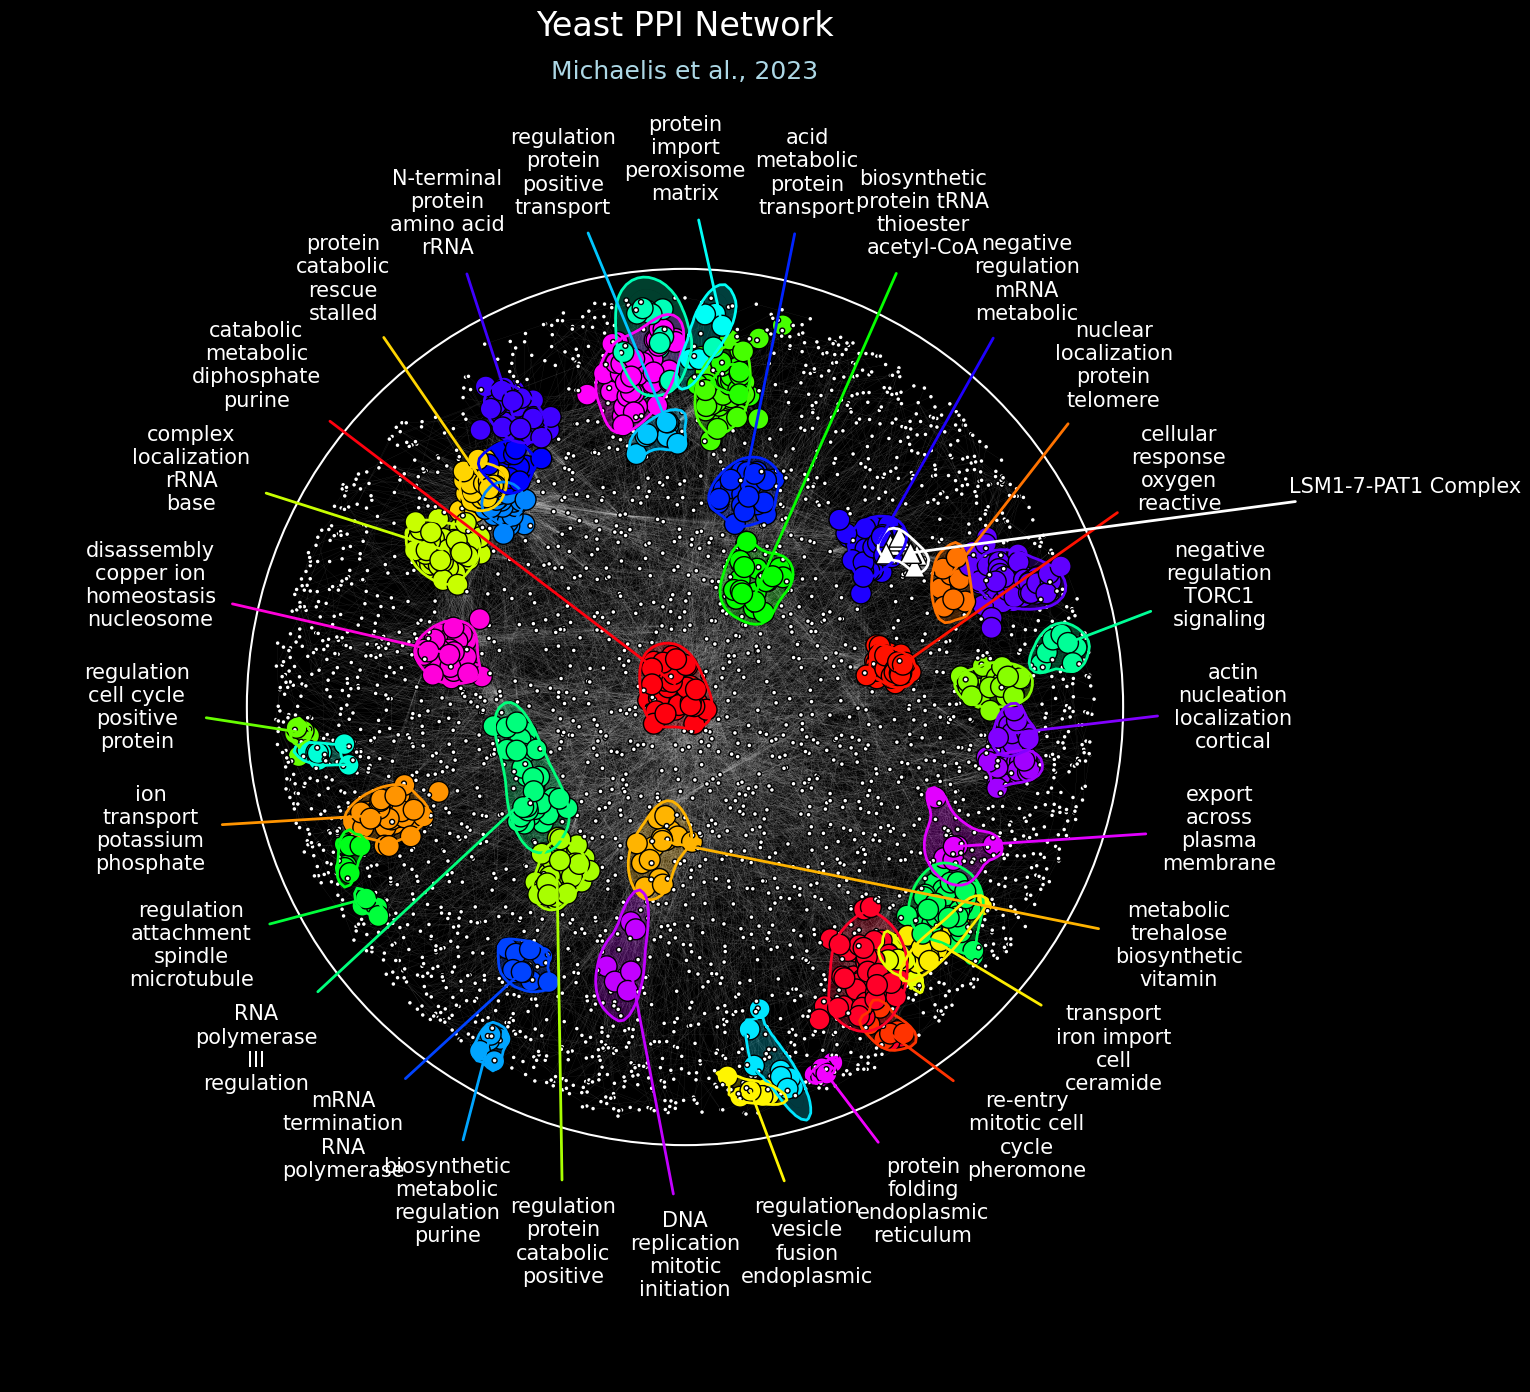

In [9]:
# Build full network plot
import matplotlib.pyplot as plt

plt.ioff()

# Set random seed for reproducibility
random_seed = 887

# Initialize the Plotter with the Graph object
plotter = risk.load_plotter(
    graph=graph,
    figsize=(15, 15),
    background_color="black",
)

# Plot network title and subtitle
plotter.plot_title(
    title="Yeast PPI Network",
    subtitle="Michaelis et al., 2023",
    title_fontsize=24,
    subtitle_fontsize=18,
    font="DejaVu Sans",
    title_color="white",
    subtitle_color="lightblue",
    title_x=0.5,
    title_y=0.925,
    title_space_offset=0.08,
    subtitle_offset=0.025,
)

# Plot network perimeter as a circle
plotter.plot_circle_perimeter(
    scale=1.02,
    center_offset_x=0.0,
    center_offset_y=0.0,
    linestyle="solid",
    linewidth=1.5,
    color="white",
    outline_alpha=1.0,
    fill_alpha=0.0,
)

# Plot network nodes and edges
plotter.plot_network(
    node_size=plotter.get_annotated_node_sizes(
        significant_size=225,
        nonsignificant_size=12.5,
    ),
    node_shape="o",
    node_edgewidth=1.0,
    edge_width=0.03,
    node_color=plotter.get_annotated_node_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        alpha=1.0,
        nonsignificant_color="white",
        nonsignificant_alpha=0.75,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    node_edgecolor="black",
    edge_color="white",
    node_alpha=1.0,
    edge_alpha=1.0,
)
# Plot a subnetwork with custom node and edge attributes
plotter.plot_subnetwork(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    node_size=225,
    node_shape="^",
    node_edgewidth=1.0,
    edge_width=0.04,
    node_color="white",
    node_edgecolor="black",
    edge_color="white",
    node_alpha=1.0,
    edge_alpha=1.0,
)

# Plot Kernel Density Estimation (KDE)-based contours around network nodes
plotter.plot_contours(
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color=plotter.get_annotated_contour_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)

# Plot custom KDE-based contours around a subset of nodes
plotter.plot_subcontour(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color="white",
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)

# Plot labels on the network
plotter.plot_labels(
    scale=1.1,
    offset=0.12,
    font="DejaVu Sans",
    fontcase={"title": "lower"},
    fontsize=15,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color=plotter.get_annotated_label_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    arrow_alpha=1.0,
    arrow_base_shrink=10.0,
    arrow_tip_shrink=0.0,
    max_labels=28,
    min_label_lines=3,
    max_label_lines=4,
    min_chars_per_line=3,
    max_chars_per_line=12,
    words_to_omit=["from", "the", "into", "via", "novo", "process", "activity"],
    overlay_ids=False,
    ids_to_keep=None,
    ids_to_labels=None,
)

# Plot sublabels on the network
plotter.plot_sublabel(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    label="LSM1-7-PAT1 Complex",
    radial_position=73,
    scale=1.6,
    offset=0.12,
    font="DejaVu Sans",
    fontsize=15,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color="white",
    arrow_alpha=1.0,
    arrow_base_shrink=10.0,
    arrow_tip_shrink=0.0,
)

# Display the plot
plotter.show()

---

## Review analysis parameters

Inspect `risk.params.load()` to review recorded settings for reproducibility and reporting.


In [10]:
# Load and display analysis parameters
import pandas as pd
from IPython.display import display

loaded_params = risk.params.load()

# Display parameters in a tidy table
pd.set_option("display.max_colwidth", 200)
display(pd.DataFrame(list(loaded_params.items()), columns=["Parameter", "Value"]))
pd.reset_option("display.max_colwidth")

------------------
Loading parameters
------------------


,Parameter,Value
0,annotation,"{'filetype': 'JSON', 'filepath': './data/json/annotation/go_biological_process.json', 'min_nodes_per_term': 5, 'max_nodes_per_term': 75}"
1,datetime,2026-08-12 10:14:43
2,graph,"{'tail': 'right', 'pval_cutoff': 0.05, 'fdr_cutoff': 1.0, 'display_prune_threshold': 0.125, 'linkage_criterion': 'distance', 'linkage_method': 'single', 'linkage_metric': 'sokalmichener', 'linkage..."
3,clusters,"{'clustering': 'louvain', 'fraction_shortest_edges': 0.25, 'resolution': 5.0, 'random_seed': 887}"
4,network,"{'compute_sphere': True, 'surface_depth': 0.1, 'min_edges_per_node': 1, 'filetype': 'Cytoscape', 'filepath': './data/cytoscape/michaelis_2023.cys'}"
5,plotter,"{'figsize': (15, 15), 'background_color': 'black', 'background_alpha': 1.0, 'pad': 0.3, 'title': 'Yeast PPI Network', 'subtitle': 'Michaelis et al., 2023', 'title_fontsize': 24, 'subtitle_fontsize..."
